# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

<div class="alert alert-block alert-success">

# ¡Hola Johan!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión. Corregiré algunas imprecisiones de la review de Dot y te dejaré mis propias recomendaciones o felicitaciones. 

Un gusto acompañarte en este proceso, vamos a ello!

### Comentario General Iteración #2

Quiero dejarte aqui la apreciacion general del proyecto para que sepas en lo que debes enfocarte y luego vas punto por punto revisando mis recomendaciones. 

Respecto a tu trabajo en esta segunda iteración, felicitarte porque has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets para llegar a las respuestas de negocio que se buscaban en este proyecto. Solo quedan algunas recomendaciones de mejora que te servirán para mejorar tus entregas a futuro y corregir el desarrollo. 

Sigue aprendiendo bastante en este camino, excelente trabajo!
</div>

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

Se descarga de manera local cada uno de los archivos suministrados para revisar de manera general su contenido y establecer los parametros adecuados para que la funcion pd.read_csv() se pueda ejecutar. Es de suma importancia llamar a las librerias necesarias para trabajar en todo el proyecto y evitar errores en los procesos posteriores. En el presente proyecto, se importan las librerias de pandas, numpy y pyplot con sus correspondientes alias. Luego de leer cada archivo, se imprimira una pequeña muestra de 10 filas por cada Data Frame creado, para observar brevemente los datos; en complemento, se llamara al metodo info, para conocer cuantas filas hay en cada Data Frame y el tipo de datos en cada una de sus columnas

In [1]:
# importar librerías
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# leer conjuntos de datos en los DataFrames
df_instacart_orders = pd.read_csv("/datasets/instacart_orders.csv", sep = ';')
df_products = pd.read_csv("/datasets/products.csv", sep = ';')
df_order_products = pd.read_csv("/datasets/order_products.csv", sep = ';')
df_aisles = pd.read_csv("/datasets/aisles.csv", sep = ';')
df_departments = pd.read_csv("/datasets/departments.csv", sep = ';')

In [3]:
# mostrar información del DataFrame
print(df_instacart_orders.sample(10))
print()
df_instacart_orders.info()

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
243177   1726521    60692             6          4                 22   
361171   3015504   132521            23          5                  7   
384340    712247   146994            15          1                 14   
457200   1756457   195889             2          3                 15   
278691   1499702    30536             2          0                 19   
6119      483290   105444             3          5                 22   
226127   1493423   120317             6          0                  9   
207414    173468   163312            10          5                 22   
425749   1036337    16086             4          1                 13   
182930   2730871    56840             8          0                 11   

        days_since_prior_order  
243177                    30.0  
361171                    30.0  
384340                     6.0  
457200                     2.0  
278691                     7.0 

In [4]:
# mostrar información del DataFrame
print(df_products.sample(10))
print()
df_products.info()

       product_id                                 product_name  aisle_id  \
35936       35937       Sugar Free Chocolate Fudge Brownie Mix       105   
15670       15671             Quinoa Puffs- Herbes de Provence       107   
25708       25709                            Wheat Dinner Roll        43   
12058       12059                             Cacao Almondmilk        91   
47840       47841                                Raisin Snails        93   
21587       21588                                          NaN       100   
34375       34376   Cream of Chicken & Mushroom Condensed Soup        69   
12789       12790                    0% Fat Peach Greek Yogurt       120   
11158       11159  Organic Dark Chocolate Almond Nutrition Bar         3   
49620       49621                                Challah Bread       112   

       department_id  
35936             13  
15670             19  
25708              3  
12058             16  
47840              3  
21587             21  
34

In [5]:
# mostrar información del DataFrame
print(df_order_products.sample(10))
print()
df_order_products.info(show_counts=True)

         order_id  product_id  add_to_cart_order  reordered
489876    1651191       21903               11.0          1
2972903    652708       34050                7.0          1
1157787   1630798       47626                8.0          1
4019384   1803475       41836               16.0          1
1112203    941343       15947                5.0          1
2719403    258256        6592               18.0          0
3976604    910876       33294               16.0          0
2126095   3381463        6184                8.0          1
701325    3165323       21137                1.0          1
1486172   3231031       20144                3.0          1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  454

In [6]:
# mostrar información del DataFrame
print(df_aisles.head(10))
print()
df_aisles.info()

   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation
5         6                       other
6         7               packaged meat
7         8             bakery desserts
8         9                 pasta sauce
9        10            kitchen supplies

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [7]:
# mostrar información del DataFrame
print(df_departments)
print()
df_departments.info()

    department_id       department
0               1           frozen
1               2            other
2               3           bakery
3               4          produce
4               5          alcohol
5               6    international
6               7        beverages
7               8             pets
8               9  dry goods pasta
9              10             bulk
10             11    personal care
11             12     meat seafood
12             13           pantry
13             14        breakfast
14             15     canned goods
15             16       dairy eggs
16             17        household
17             18           babies
18             19           snacks
19             20             deli
20             21          missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.


En el analisis previo, se observa que los valores de los archivos estaban separados por ";". Por lo tanto se tuvo que establecer el argumento sep = ";" en read_csv(), para conformar correctamente los data frames. En cuanto a los nombres de las columnas, estas ya tienen una presentacion adecuada en minusculas, sin caracteres especiales, sin espacios presentes y en formano "snake_case". 

Es importante mencionar que la mayoria de las columnas en los Data Frames son de tipo cuantitativo. Lo cual permitira hacer calculos aritmeticos o estadisticos de una manera adecuada. No obstante, las columnas categoricas como el nombre del producto, nombre de pasillo o nombre de departamento, permitiran agrupar los datos para observar frecuencias de compras de productos o para imprimir graficos que expliquen mejor lo que a las variables cuantitativas les falta. 

Todos los Data Frame tienen un indice de completitud alto, lo cual indica que existen pocos valores ausentes. Dicha situacion se presenta de manera positiva porque se pueden gestionar los valores ausentes sin afectar de manera significativa el contenido estadistico del Data Frame. Acatando las instrucciones encontradas en el instructivo de desarrollo del proyecto, fue necesario establecer el parametro "show_counts=True" en el metodo info () del Data Frame "order_products", ya que era necesario conocer la cantidad de filas y valores no nulos en este Data Frame, el cual supera los 4.5 millones de registros.

En el presente proyecto se suministraron 5 archivos, los cuales se convierten en 5 Data Frames. En el analisis previo se observa que varios Data Frame comparten columnas, tal como en el caso de "order_id" que esta presente en df_instacart_orders y df_order_products; tambien se puede observar que "product_id" se encuentra en df_products y df_order_products. Dicha distribucion de los datos puede ser de gran utilidad para obtener unir diferentes data frames y obtener diferentes resultados en comparacion de estudiarlos por separado. 

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

1) Verificar que existan duplicados en cada Data Frame
2) Observar los valores duplicados, analizar el contexto de su existencia y borrar aquellos que no aporten al analisis posterior.
3) Para comprobar la existencia de valores duplicados en columnas tipo "object", se realizara una esdandarizacion previa(Convertir en mayusculas), para que se pueda realizar una sentencia que los compare a TODOS los caracteres de manera unitaria y NO queden valores sin comparar
4) Reemplazar los valores ausentes en columnas especificas, dependiento del tipo de datos que esten conteidas en ellas
5) Convertir tipos de datos de las columnas solicitadas.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
print('Existen', df_instacart_orders.duplicated().sum(), 'duplicados')

Existen 15 duplicados


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

In [9]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
print('Pedidos realizados el miercoles a las 2am: \n\n', df_instacart_orders[(df_instacart_orders['order_dow']==3) & (df_instacart_orders['order_hour_of_day']==2)])

Pedidos realizados el miercoles a las 2am: 

         order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156       

In [10]:
# Elimina los pedidos duplicados
df_instacart_orders.drop_duplicates(inplace=True)

In [11]:
# Vuelve a verificar si hay filas duplicadas
print(f"Ahora existen {df_instacart_orders.duplicated().sum()} duplicados")

Ahora existen 0 duplicados


In [12]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
print("IDs duplicados:",df_instacart_orders['order_id'].duplicated().sum())

IDs duplicados: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos

1) Consultar si hay valores duplicados aplicando "duplicated().sum()" al Data Frame.
2) Imprimir dichos valores con la funcion print(). Este paso permite verificar que las ordenes duplicadas se realizaron un miercoles a las 2 am.
3) Borrar duplicados y actualizar el df con la sentencia "drop_duplicates(inplace=True)".
4) Verificar nuevamente si existen duplicados en el DF y en la columna 'order_id'

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Hiciste una correcta eliminación de los duplicados. Te recomiendo solamente usar `reset_index(drop=True)` para que un buen manejo de indices al realizar el proceso de limpieza. 

### `products` data frame

In [15]:
# Verifica si hay filas totalmente duplicadas
print('Existen', df_products.duplicated().sum(), 'duplicados')

Existen 0 duplicados


In [16]:
# Revisa únicamente si hay ID de productos duplicados
print("IDs de productos duplicados:",df_products['product_id'].duplicated().sum())

IDs de productos duplicados: 0


In [17]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
print(df_products['product_name'].str.upper().sample(10), "\n\n")
print("Productos duplicados:", df_products['product_name'].str.upper().duplicated().sum())

30046                                LONG ITALIAN BAGUETTE
3849                                    SNOWFLAKE CRACKERS
39512                       ORGANIC GROUND PEELED TOMATOES
6084      CHOPPED CHICKEN MEATY GROUND DINNER WET DOG FOOD
1849                          LASAGNA BAKE WITH MEAT SAUCE
20641    VITAMINTS RASPBERRY ADULT MULTIVITAMIN MINTY C...
42537                       ORGANIC APPLESAUCE APPLE POUCH
30705                                        805 BLOND ALE
5147                         STRAWBERRY BABY YOGURT BLENDS
3488                                        LEMON SQUEEZER
Name: product_name, dtype: object 


Productos duplicados: 1361


In [18]:
# Revisa si hay nombres duplicados de productos no faltantes
no_faltantes = df_products[df_products['product_name'].notna()]
print("Productos no fantantes duplicados:",no_faltantes['product_name'].str.upper().duplicated().sum())
product_duplicado = duplicados = no_faltantes[no_faltantes['product_name'].str.upper().duplicated()]
print()
print(product_duplicado['product_name'].str.upper())

Productos no fantantes duplicados: 104

2058                                     BIOTIN 1000 MCG
5455                    GREEN TEA WITH GINSENG AND HONEY
5558                              CREAM OF MUSHROOM SOUP
7558                           CINNAMON ROLLS WITH ICING
9037                              AMERICAN CHEESE SLICES
                              ...                       
49689                      HIGH PERFORMANCE ENERGY DRINK
49690                      ORIGINAL PANCAKE & WAFFLE MIX
49691    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR
49692                             SPRING WATER BODY WASH
49693                            BURRITO- STEAK & CHEESE
Name: product_name, Length: 104, dtype: object


Describe brevemente tus hallazgos y lo que hiciste con ellos.

1) Consultar si hay valores duplicados aplicando "duplicated().sum()" al Data Frame.
2) Consultar si existen valores de 'product_id' duplicados
3) Consultar si hay nombres de productos que esten duplicados. Para ello, fue necesario convertir todos los nombres en mayuscula. con la finalidad de que se detectaran de manera mas eficiente los duplicados. Se obtuvo una cantidad de mas de 1000 duplicados
4) Considerando que la columna 'product_name' tiene valores ausentes representados por 'NAN', estos se pueden representar como valores duplicados, lo cual no es correcto interpretar. Es por ello que se filtra el Data Frame, para seleccionar solo las filas que tienen los productos 'NO FALTANTES' (Valores No Nulos). Con base a dicho filtro se vuelve a consultar si existen valores duplicados y se obtiene que la cantidad bajo a 104 duplicados. No obstante, tales valores se recomienda conservarlos porque cada uno cuenta con un 'product_id' que los diferencia de los demas productos. Si se borran puede alterar el registro de los pedidos o las ordenes. Por ultimo, se imprime la lista de los 104 valores duplicados para verificar que el analisis se haya realizado de manera correcta

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Hiciste un buen trabajo al no eliminar estos valores duplicados por nombre, ya que al tener el mismo nombre pero diferentes IDs puede tratarse de productos con diferentes ubicaciones o productos completamente diferentes nombrados de forma erronea.  

Excelente trabajo con la correccion de mayusculas, caracteres especiales y espacios. 

### `departments` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
print('Existen', df_departments.duplicated().sum(), 'duplicados')

Existen 0 duplicados


In [20]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print("IDs de departamentos duplicados:",df_departments['department_id'].duplicated().sum())

IDs de departamentos duplicados: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

1) Anteriormente se dio una vista previa de la informacion y los valores para cada uno de los Data Frames. Sin embargo, en el analisis del df_deparments, se evidencia que cuenta con pocas filas, las cuales describen el departemento de ubicacion de los productos y los categoriza de manera general. En la vista de todos los datos de tal df no se observan filas o IDs duplicados. 
2) Para verificar lo mencionado anteriormente, se utiliza el metodo "duplicated()" para consultar si existen filas duplicadas o valores repetidos en la columna 'department_id'

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen flujo de trabajo, completo, para verificar duplicados: comprobaste duplicados de filas completas y duplicados a nivel de ID, y tus notas escritas explican lo que implican los resultados para el análisis posterior.

</div>


### `aisles` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
print('Existen', df_aisles.duplicated().sum(), 'duplicados')

Existen 0 duplicados


In [22]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print("IDs de pasillos duplicados:",df_aisles['aisle_id'].duplicated().sum())

IDs de pasillos duplicados: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

1) Se utiliza el metodo "duplicated()" para consultar si existen filas duplicadas o valores repetidos en la columna 'aisle_id'

### `order_products` data frame

In [23]:
# Revisa si hay filas totalmente duplicadas
print('Existen', df_order_products.duplicated().sum(), 'duplicados')

Existen 0 duplicados


In [24]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print("Duplicados engañosos:",df_order_products.duplicated(subset=['order_id', 'product_id']).sum())

Duplicados engañosos: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

1) Se utiliza el metodo "duplicated()" para consultar si existen filas duplicadas en el data frame de df_order_products.
2) En cuanto a los duplicados engañosos, se reutiiza el metodo anterior, pero aplicado solo a las columnas 'order_id' y 'product_id'. Dicho proceso se realiza con la finalidad de verificar si existe un producto que se repita dos o mas veces en una orden especifica. Al no haber duplicados engañosos, se intuye que en las ordenes no hay productos repetidos, lo cual es necesario para la logica de los datos y analisis.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buena comprobación de coherencia (sanity check) en `order_products`: verificar tanto los duplicados de fila completa como los posibles duplicados engañosos por (`order_id`, `product_id`) es una forma sólida de validar la estructura del dataset.

</div>


## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [25]:
# Encuentra los valores ausentes en la columna 'product_name'
print("Valores ausentes en la culumna product_name:", df_products['product_name'].isna().sum(), "\n\n",
      df_products[df_products['product_name'].isna()].head(25))

Valores ausentes en la culumna product_name: 1258 

       product_id product_name  aisle_id  department_id
37            38          NaN       100             21
71            72          NaN       100             21
109          110          NaN       100             21
296          297          NaN       100             21
416          417          NaN       100             21
436          437          NaN       100             21
439          440          NaN       100             21
471          472          NaN       100             21
490          491          NaN       100             21
555          556          NaN       100             21
561          562          NaN       100             21
613          614          NaN       100             21
623          624          NaN       100             21
689          690          NaN       100             21
767          768          NaN       100             21
803          804          NaN       100             21
890         

Describe brevemente cuáles son tus hallazgos.

1) Los productos que no tienen nombre, se encuentran en el pasillo 100, departamento 21.

In [26]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
print("Pasillo con ID = 100:\n\n", df_products[df_products['aisle_id'] == 100].head(25))

Pasillo con ID = 100:

       product_id product_name  aisle_id  department_id
37            38          NaN       100             21
71            72          NaN       100             21
109          110          NaN       100             21
296          297          NaN       100             21
416          417          NaN       100             21
436          437          NaN       100             21
439          440          NaN       100             21
471          472          NaN       100             21
490          491          NaN       100             21
555          556          NaN       100             21
561          562          NaN       100             21
613          614          NaN       100             21
623          624          NaN       100             21
689          690          NaN       100             21
767          768          NaN       100             21
803          804          NaN       100             21
890          891          NaN       100  

Describe brevemente cuáles son tus hallazgos.

1) Se realiza una sentecia que imprima los primeros 25 valores de pasillo iguales a 100. Al ver el resualtado se obtienen las mismas filas que se observaron al consultar los valores nulos de Nombres de Producto
2) En complemento se observa que los valores nulos en la columna 'product_name' y los valores iguales a 100 en la columna 'aisle_id' son de un total de 1258 en cada una de ellas, lo que puede inferir que los productos del pasillo con ID 100 no tienen un nombre asociado.

In [27]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print("Departamento con ID = 21:\n\n", df_products[df_products['department_id'] == 21].head(25))

Departamento con ID = 21:

       product_id product_name  aisle_id  department_id
37            38          NaN       100             21
71            72          NaN       100             21
109          110          NaN       100             21
296          297          NaN       100             21
416          417          NaN       100             21
436          437          NaN       100             21
439          440          NaN       100             21
471          472          NaN       100             21
490          491          NaN       100             21
555          556          NaN       100             21
561          562          NaN       100             21
613          614          NaN       100             21
623          624          NaN       100             21
689          690          NaN       100             21
767          768          NaN       100             21
803          804          NaN       100             21
890          891          NaN       1

Describe brevemente cuáles son tus hallazgos.

1) Al igual que en la consulta con los pasillos, se observa que aquellos productos que se encuentran en el departamento 21, NO tienen un nombre asociado. Ademas, dichas filas son los mismas que las obtenidas al revisar los valores nulos de la columna 'product_name'. 

In [28]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
print("Datos pasillo 100: \n", df_aisles[df_aisles['aisle_id']==100])
print()
print("Datos departamento 21: \n", df_departments[df_departments['department_id']==21])

Datos pasillo 100: 
     aisle_id    aisle
99       100  missing

Datos departamento 21: 
     department_id department
20             21    missing


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Sólida investigación de los valores faltantes de `product_name`: los rastreaste hasta el pasillo/departamento 'missing' y luego los completaste de forma consistente (p. ej., con 'Unknown'), confirmando después que no quedan valores nulos. Este es un manejo bien justificado de la falta de datos categóricos.

</div>


Describe brevemente cuáles son tus hallazgos.

1) El pasillo 100 y el departamento 21 cuentan con el mismo valor. En un analisis del contexto de la tienda, se puede interpretar que existe un pasillo y un departamento especificos para acomodar aquellos productos que no tienen nombre, ya sea porque no cuentan con un empaque legible o porque puede ser un tipo de producto que no viene con un nombre especifico.
2) En dicho orden de ideas, se deben conservar tales valores aunque esten denominados como ausentes. No obstante, esta denominacion se debe reemplazar para evitar confusiones.

In [29]:
# Completa los nombres de productos ausentes con 'Unknown'
df_products['product_name'].fillna('Unknown', inplace=True)
print("Valores ausentes después del reemplazo:", df_products['product_name'].isna().sum())

Valores ausentes después del reemplazo: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

1) Se utiliza el metodo Fillna() para reemplazar los valores ausentes por 'Unknown' en la columna de 'product_name' y evitar su eliminacion.
2) Posteriormente se vuelve a ejecutar una sentencia que verifica si existen valores nulos. El resultado esperado se dio y ya no existen valores ausentes en dicha columna.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Muy bien! Hiciste un buen trabajo al ahondar en los datos ausentes y su correspondencia con las tablas de pasillos y departamentos. Hiciste el correcto reemplazo de valores ausentes. 

### `orders` data frame

In [30]:
# Encuentra los valores ausentes
print("Valores ausentes:\n\n", df_instacart_orders[df_instacart_orders['days_since_prior_order'].isna()])

Valores ausentes:

         order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100 

In [31]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
print("Primer pedido:\n\n", df_instacart_orders[df_instacart_orders['order_number']==1])

Primer pedido:

         order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100    

Describe brevemente tus hallazgos y lo que hiciste con ellos.

1) La cantidad de valores ausentes en 'days_since_prior_order' es el mismo que 'order_number' igual a 1 (28817), lo que quiere decir, que tales valores ausentes existen porque los clientes hicieron su primera compra y no habia registro de ellos en compras anteriores.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente. Encontraste que si se encuentran ordenes que sean el primer pedido del cliente, es normal que no tengamos información sobre cuántos días han pasado desde su último pedido (days_since_prior_order), por lo cual son filas que se mantienen sin cambios. 

### `order_products` data frame

In [32]:
# Encuentra los valores ausentes
#df_order_products.info(show_counts=True)
print("Valores ausentes:\n\n", df_order_products[df_order_products['add_to_cart_order'].isna()])

Valores ausentes:

          order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [33]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print("Valor minimo:", df_order_products['add_to_cart_order'].min())
print("Valor maximo:", df_order_products['add_to_cart_order'].max())

Valor minimo: 1.0
Valor maximo: 64.0


Describe brevemente cuáles son tus hallazgos.

1) Puede existir una alta demanda de productos por cliente. Existe uno o mas clientes que hacen compras de mas de 60 articulos

In [34]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
ausentes_add_to_car = df_order_products[df_order_products['add_to_cart_order'].isna()]
print(ausentes_add_to_car)

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [35]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

conteo = ausentes_add_to_car.groupby('order_id')['product_id'].count()
print("Conteo:\n", conteo)
print()
print("Valor minimo:", conteo.min())
#print("Valor maximo:", conteo.max())

Conteo:
 order_id
9310        1
61355      63
102236     31
129627      5
165801      6
           ..
2999801     6
3125735    22
3308010    51
3347453     7
3383594     5
Name: product_id, Length: 70, dtype: int64

Valor minimo: 1


Describe brevemente cuáles son tus hallazgos.

1) Ningun pedido cuenta con mas de 64 productos
2) Los pedidos con valores ausentes varian desde 1 hasta 63 productos

In [36]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
df_order_products['add_to_cart_order'].fillna(999, inplace=True)
df_order_products['add_to_cart_order'] = df_order_products['add_to_cart_order'].astype(int)
df_order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           4545007 non-null  int64
 1   product_id         4545007 non-null  int64
 2   add_to_cart_order  4545007 non-null  int64
 3   reordered          4545007 non-null  int64
dtypes: int64(4)
memory usage: 138.7 MB


Describe brevemente tus hallazgos y lo que hiciste con ellos.

1) Se reemplazan los valores ausentes en 'add_to_cart_order' por el valor de 999 y posteriormente se convierte dicha columna en tipo entero.
2) Se verifica nuevamente la presencia de valores ausentes con el metodo info(). Ahora, todas las columnas no tienen valores ausentes y son de tipo entero

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos


1) Es importante conocer el contexto y el significado de los datos suministrados. El hecho de contar con un diccionario de datos que explicara el contenido de cada una de las columnas, ayuda a realizar una correcta interpretacion de los mismos y evita la eliminacion de datos que pueden ser relevantes en un analisis posterior.
   
2) La gestion adecuada de los valores nulos ayuda a estandarizar los datos y conservar aquellos que son relevantes. lo anterior, se puede representar cuando se interpretan a los valores ausentes como duplicados. En el procesamiento de datos, se evidencia que existian valores nulos como duplicados, lo cual puede ser incorrecto segun el contexto.

3) En complemento, se debe entender la relacion de los datos en un Data Frame o en el analisis conjunto de varios, para evitar la eliminacion de duplicados engañosos.

4) Por ultimo, se concluye que no todos los valores ausentes NO tienen un significado. Dentro de un analisis correcto, se debe entender que la explicacion de los valores ausentes en una columna se puede encontrar a partir del analisis de las otras, como lo fue en el caso de los productos que no tenian un nombre asociado. Al observar las columnas de pasillo y departamento, se concluye que estos productos (SIN NOMBRE) encajaban perfectamente en una categoria de la tienda. 

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [37]:
print("Rango de horas del dia en las que se realizan pedidos:\n\n", sorted(df_instacart_orders['order_hour_of_day'].unique()))

Rango de horas del dia en las que se realizan pedidos:

 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [38]:
print("Rango de dias en los que se realizan pedidos:\n\n", sorted(df_instacart_orders['order_dow'].unique()))

Rango de dias en los que se realizan pedidos:

 [0, 1, 2, 3, 4, 5, 6]


Escribe aquí tus conclusiones

Las columnas que indican la temporalidad de los pedidos tienen consistencia logica, ya que la columna de horas varia en 24 unicos valores, representados en las horas del dia. En cuanto la columna semana, su rango tiene 7 unicos valores, los cuales estan representados en los dia de la semama.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Validación clara: confirmaste que tanto `order_hour_of_day` como `order_dow` se encuentran dentro de los rangos esperados y resumiste lo que eso implica sobre la calidad de los datos.

</div>


### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

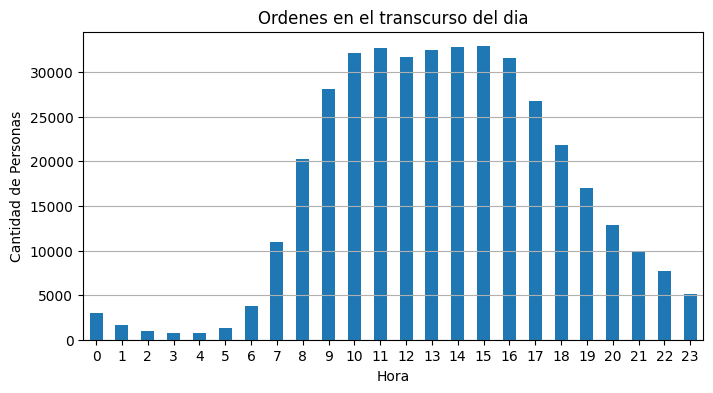

In [39]:
conteo_hora = df_instacart_orders.groupby('order_hour_of_day')['user_id'].nunique().sort_index()

conteo_hora.plot(kind='bar',
                 title='Ordenes en el transcurso del dia',
                 xlabel='Hora',
                 ylabel='Cantidad de Personas',
                 figsize=[8, 4],
                 rot=0) 
plt.grid(True, axis='y')
plt.show()

Escribe aquí tus conclusiones

Existe una zona horaria donde hay una mayor cantidad de pedidos, debido a que es el tiempo en el que las pesornas comen su almuerzo. Se puede inferir que las personas que utilizan la plataforma de Instacart, son aquellas que no cuentan con tiempo o disponibilidad para cocinar debido a sus obligaciones laborales o academicas. Es por eso que esta plataforma ofrece una oportunidad para obtener comida a domicilio, omitiendo el proceso previo de preparacion, lo cual les permite ahorrar su tiempo. 

La demanda disminuye en las mañanas y en las noches porque la mayoria de las personas estan en sus hogares y cuentan con el tiempo y los ingredientes para preparar su propia comida. 

### [A3] ¿Qué día de la semana compran víveres las personas?

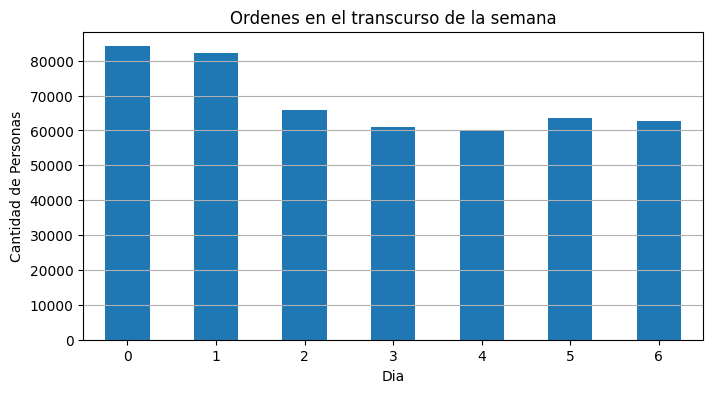

In [40]:
conteo_dia = df_instacart_orders['order_dow'].value_counts().sort_index()
conteo_dia.plot(kind='bar',
                title='Ordenes en el transcurso de la semana',
                xlabel='Dia',
                ylabel='Cantidad de Personas',
                figsize=[8, 4],
                rot=0) 
plt.grid(True, axis='y')
plt.show()

Escribe aquí tus conclusiones

El dia en el que se presenta una mayor catidad de pedidos, puede explicar su comportamiento de varias maneras:
1) Como representa el dia de descanso (Domingo) para la mayoria de personas, estas aprovechan para solicitar un domicilio y evitar la necesidad de cocinar.
2) En complemento, varias de esas personas aprovechan los dias de descanso para mercar. Cabe recordar, que la plataforma cuenta con una amplia gama de productos, y no solo de comidas preparadas. Algunas personas estan conociendo que ya se puede hacer mercado por medio de plataformas y obtan por dicha alternativa por sus beneficios de tiempo y el no transportarse hasta el supermercado.

No obstante, el dia Lunes tambien se presenta una gran cantidad de pedidos. Este comportamiento se puede presentar por las personas que hacen la compra de viveres de toda la semana. 

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

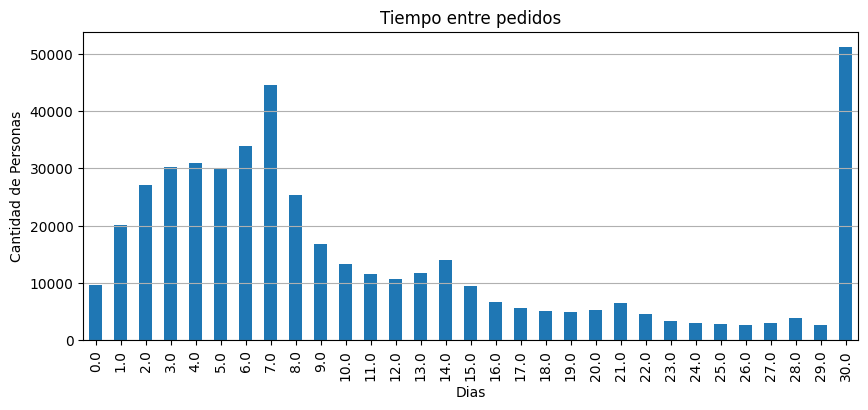

Mayor tiempo de espera para realizar otro pedido: 30.0

Menor tiempo de espera para realizar otro pedido: 0.0


In [41]:
tiempo_espera = df_instacart_orders['days_since_prior_order'].value_counts().sort_index()
tiempo_espera.plot(kind='bar',
                   title='Tiempo entre pedidos',
                   xlabel='Dias',
                   ylabel='Cantidad de Personas',
                   xlim=[0,30],
                   figsize=[10, 4],
                   rot=90) 
plt.grid(True, axis='y')
plt.show()
print("Mayor tiempo de espera para realizar otro pedido:", df_instacart_orders['days_since_prior_order'].max())
print()
print("Menor tiempo de espera para realizar otro pedido:", df_instacart_orders['days_since_prior_order'].min())

Escribe aquí tus conclusiones

El valor maximo (30) se puede interpretar como una frecuencia mensual. Es decir, un gran numero de clientes esperan alrededor de un mes para realizar otro pedido en la aplicacion; dicho fenomeno puede estar relacionado al momento en el que las personas reciben el dinero proveniente de su trabajo u otra actividad economica para hacer las compras de comida.

En cuanto al valor minimo de dias de espera (26), se puede inferir que es un dia que cabe en una franja temporal en la que las personas cuentan con menor poder adquisitivo, debido a que realizaron sus gastos correspondientes en las 2 primeras semanas del mes. Al no haber dinero disponible para la gente, genera que disminuya la demanda y las personas deban esperar hasta que les llegue el dinero de su actividad economica predominante, que por lo generar proviene de sus trabajos. Cabe hacer la claridad, debido a que en la mayoria de trabajos, se realizan los pagos con una temporalidad mensual

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente! Los gráficos que presentas muestran claramente cada una de las mediciones solicitadas, tienen una buena presentación de ejes y etiquetado correcto. Tus conclusiones son muy buenas, respecto a las horas y los días en que los usuarios hacen mayores compras. 

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [42]:
ped_miercoles = df_instacart_orders[df_instacart_orders['order_dow'] == 3]
ord_miercoles = ped_miercoles['order_hour_of_day'].value_counts().sort_index()
print(ord_miercoles)

0      373
1      215
2      106
3      101
4      108
5      170
6      643
7     1732
8     3125
9     4490
10    5026
11    5004
12    4688
13    4674
14    4774
15    5163
16    4976
17    4175
18    3463
19    2652
20    1917
21    1450
22    1154
23     718
Name: order_hour_of_day, dtype: int64


In [43]:
ped_sabado = df_instacart_orders[df_instacart_orders['order_dow'] == 6]
ord_sabado = ped_sabado['order_hour_of_day'].value_counts().sort_index()
print(ord_sabado)

0      464
1      254
2      177
3      125
4      118
5      161
6      451
7     1619
8     3246
9     4311
10    4919
11    5116
12    5132
13    5323
14    5375
15    5188
16    5029
17    4295
18    3338
19    2610
20    1847
21    1473
22    1185
23     893
Name: order_hour_of_day, dtype: int64


In [44]:
df_miercoles = ord_miercoles.to_frame(name='Miercoles')
df_sabado = ord_sabado.to_frame(name='Sabado')

frecuencias_mier_sab = df_miercoles.merge(df_sabado, left_index=True, right_index=True)
print(frecuencias_mier_sab)

    Miercoles  Sabado
0         373     464
1         215     254
2         106     177
3         101     125
4         108     118
5         170     161
6         643     451
7        1732    1619
8        3125    3246
9        4490    4311
10       5026    4919
11       5004    5116
12       4688    5132
13       4674    5323
14       4774    5375
15       5163    5188
16       4976    5029
17       4175    4295
18       3463    3338
19       2652    2610
20       1917    1847
21       1450    1473
22       1154    1185
23        718     893


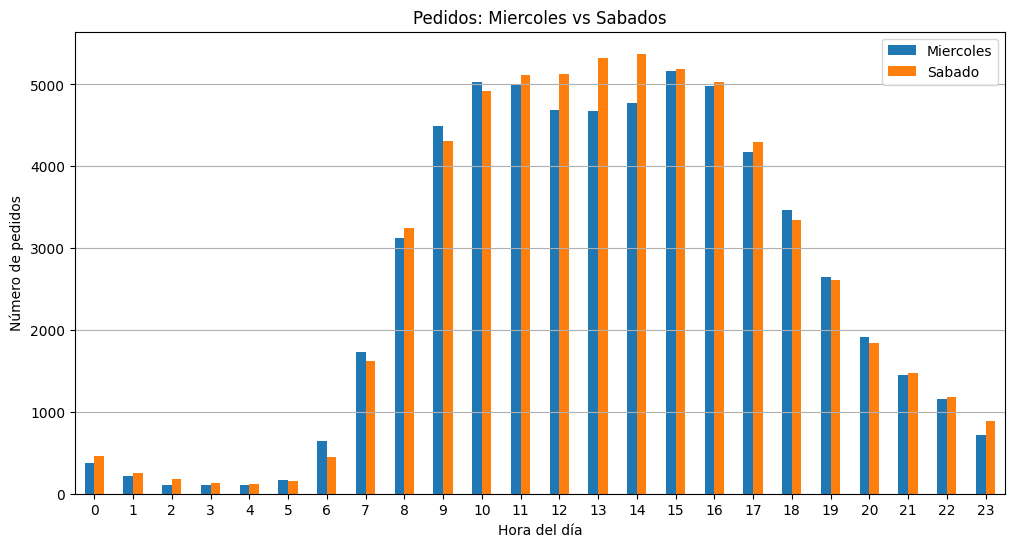

In [45]:
frecuencias_mier_sab.plot(kind='bar',
                         title='Pedidos: Miercoles vs Sabados',
                         xlabel='Hora del día',
                         ylabel='Número de pedidos',
                         figsize=[12, 6],
                         rot=0)
plt.grid(True, axis='y')
plt.legend(['Miercoles', 'Sabado'])
plt.show()

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen trabajo al presentar ambas distribuciones en un solo gráfico con etiquetas claras y luego comentar las diferencias que observaste.

</div>


Escribe aquí tus conclusiones

Ambos dias presentan un comportamiento similar en cuanto a las horas en las que realizan los pedidos. Sin embargo, existe una diferencia notable en la franja de (12-14), la cual indica que hay un mayor numero de pedidos el dia sabado. Este comportamiento puede deberse a que el dia sabado pertenece a uno de los dias de descanso y los consumidores contemplan la opcion de pedir domicilios, para evitar la preparacion de los alimentos que tienen en casa. En complemento, el aumento de consumo en tales horas se puede reflejar en productos que ya estan cocinados, como las comidas rapidas.

Al igual que los graficos y analisis anteriores, se nota de diferentes maneras una tendencia notable por el uso de la plataforma de las personas, los dias que estan asignados para el descanso.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [46]:
pedidos_cliente = df_instacart_orders.groupby('user_id')['order_number'].count()
pedidos_cliente = pedidos_cliente.value_counts()
print(pedidos_cliente)

1     55357
2     36508
3     21547
4     13498
5      8777
6      6012
7      4240
8      3019
9      2152
10     1645
11     1308
12      947
13      703
14      512
15      437
16      263
17      184
18      121
19       85
20       52
22       23
21       22
23       19
24        3
25        1
26        1
28        1
Name: order_number, dtype: int64


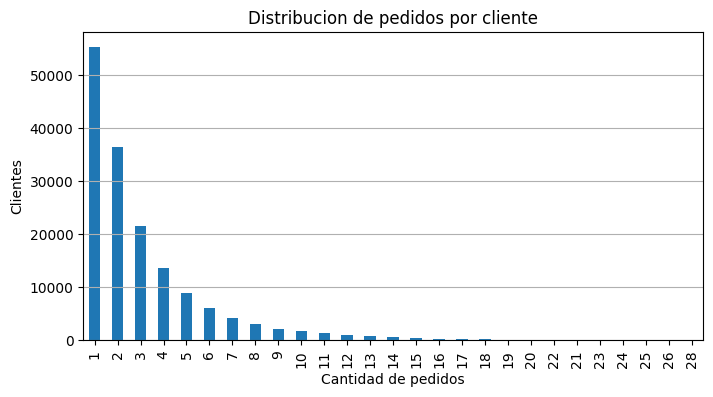

In [47]:
pedidos_cliente.plot(kind='bar',
                     title='Distribucion de pedidos por cliente',
                     xlabel='Cantidad de pedidos',
                     ylabel='Clientes',
                     figsize=[8, 4],
                     xlim=[0, 100],
                     rot=90) 
plt.grid(True, axis='y')
plt.show()

Escribe aquí tus conclusiones

Se puede inferir que la plataforma de Instacart lleva poco tiempo en el mercado de aplicaciones, debido a que pocos clientes la han hecho mas de 10 pedidos. A pesar de ello, se ha visto que existe una cantidad considerable de clientes que han hecho de 1 a 5 pedidos.

En el futuro, dicha tendencia puede crecer y el numero de clientes que realicen mas de 20 pedidos, puede aumentar.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buena realización de la distribución de “orders per customer”: la lógica de agregación coincide con la pregunta, e incluiste una gráfica además de su interpretación.

</div>


### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [48]:
conteo_productos = df_order_products['product_id'].value_counts()
print(conteo_productos.head(20))

24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
47766    24689
47626    21495
16797    20018
26209    19690
27845    19600
27966    19197
22935    15898
24964    15292
45007    14584
39275    13879
49683    13675
28204    12544
5876     12232
8277     11993
40706    11781
Name: product_id, dtype: int64


In [49]:
df_mas_populares = conteo_productos.reset_index()
df_mas_populares.columns = ['product_id', 'cantidad_pedidos']
print(df_mas_populares.head(20))

    product_id  cantidad_pedidos
0        24852             66050
1        13176             53297
2        21137             37039
3        21903             33971
4        47209             29773
5        47766             24689
6        47626             21495
7        16797             20018
8        26209             19690
9        27845             19600
10       27966             19197
11       22935             15898
12       24964             15292
13       45007             14584
14       39275             13879
15       49683             13675
16       28204             12544
17        5876             12232
18        8277             11993
19       40706             11781


In [50]:
populares_nombre = df_mas_populares.merge(df_products, on='product_id', how='left')
print(populares_nombre.head(20))
print("\n\nPasillo:\n", df_aisles[df_aisles['aisle_id']==24])
print("\n\nDepartamento:\n", df_departments[df_departments['department_id']==4])

    product_id  cantidad_pedidos              product_name  aisle_id  \
0        24852             66050                    Banana        24   
1        13176             53297    Bag of Organic Bananas        24   
2        21137             37039      Organic Strawberries        24   
3        21903             33971      Organic Baby Spinach       123   
4        47209             29773      Organic Hass Avocado        24   
5        47766             24689           Organic Avocado        24   
6        47626             21495               Large Lemon        24   
7        16797             20018              Strawberries        24   
8        26209             19690                     Limes        24   
9        27845             19600        Organic Whole Milk        84   
10       27966             19197       Organic Raspberries       123   
11       22935             15898      Organic Yellow Onion        83   
12       24964             15292            Organic Garlic      

Escribe aquí tus conclusiones

Observando los nombres de los productos y el pasillo en el que se encuentran, se marca una fuerte tendencia en la que las personas estan cambiando sus habitos de consumo por aquellos que les parezcan mas saludables y naturales. Dicho comportamiento, fortalece el estilo de vida actual, en el que se prioriza tener habitos mas sanos tanto fisicos como mentales.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Identificaste correctamente los 20 productos pedidos con mayor frecuencia y mostraste tanto los IDs de producto como los nombres mediante un merge apropiado.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Vamos por partes: 
- En la parte B1 hiciste correctamente la comparacion entre los dias miercoles y sabado, reconociendo como los picos de un dia son mas bajos en el otro. Muy buen uso del histograma combinando ambos datos con diferenciador por color.
- En el inciso B2 hiciste un buen uso del histograma, concluyendo correctamente sobre los habitos de los usuarios.
- En el inciso B3 hiciste un excelente uso de `merge` para obtener el top de productos con sus identificadores y nombres. 

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [51]:
productos_pedido = df_order_products.groupby('order_id')['add_to_cart_order'].count()
df_productos_pedido = productos_pedido.reset_index()
df_productos_pedido.columns = ['order_id', 'cantidad_productos']

print(df_productos_pedido.head(20))

    order_id  cantidad_productos
0          4                  13
1          9                  15
2         11                   5
3         19                   3
4         20                   8
5         31                  10
6         48                   8
7         56                  10
8         61                  12
9         68                   9
10        75                  16
11        80                   7
12        81                  11
13        83                  14
14        99                   7
15       114                  10
16       131                  18
17       142                   7
18       143                  25
19       148                  14


In [52]:
distribucion = df_productos_pedido['cantidad_productos'].value_counts().sort_index()
distribucion_primeros = distribucion[distribucion.index <= 40]
distribucion_ultimos = distribucion.tail(40)
print("Total distribucion:\n\n",distribucion,"\n\n")
print("Mayores Frecuencias:\n\n",distribucion_primeros,"\n\n")
print("Menores Frecuencias:\n\n",distribucion_ultimos,"\n\n")

Total distribucion:

 1      21847
2      26292
3      29046
4      31054
5      31923
       ...  
98         1
104        1
108        1
115        1
127        1
Name: cantidad_productos, Length: 90, dtype: int64 


Mayores Frecuencias:

 1     21847
2     26292
3     29046
4     31054
5     31923
6     31698
7     30822
8     28539
9     25742
10    23248
11    20406
12    18539
13    16497
14    14472
15    12696
16    11465
17    10002
18     8726
19     7612
20     6771
21     5738
22     5096
23     4422
24     3838
25     3382
26     2812
27     2458
28     2137
29     1899
30     1618
31     1328
32     1171
33     1003
34      845
35      686
36      587
37      508
38      475
39      377
40      335
Name: cantidad_productos, dtype: int64 


Menores Frecuencias:

 51     64
52     41
53     52
54     34
55     28
56     25
57     27
58     14
59     17
60     13
61     16
62     11
63     12
64      5
65      9
66      5
67      6
68      2
69      6
70      6
71      3
72 

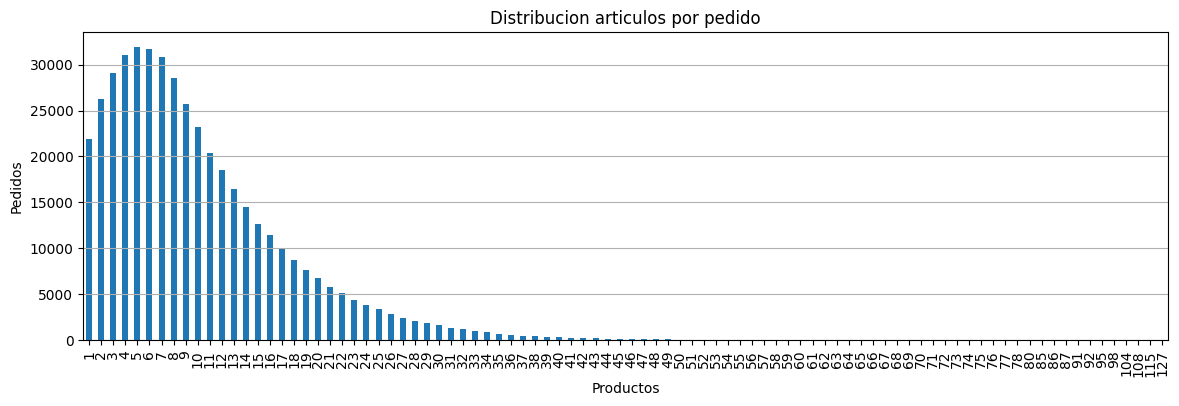

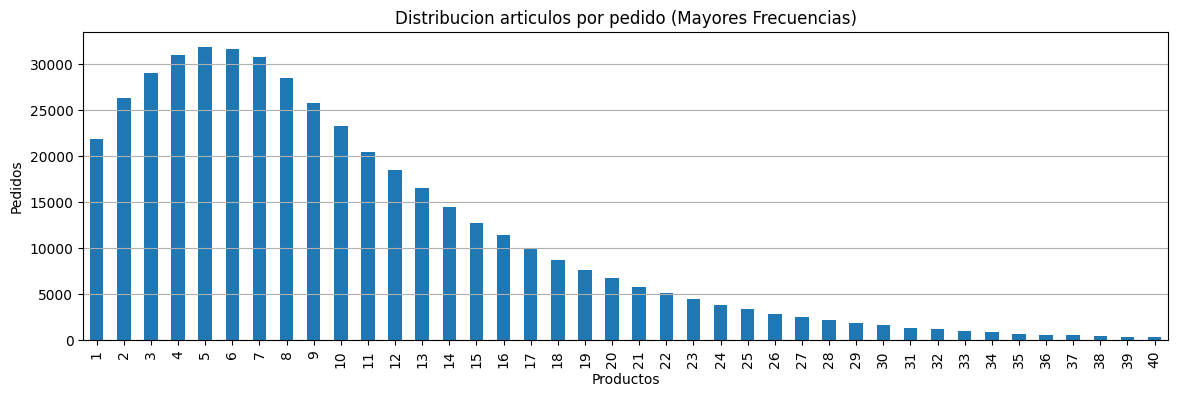

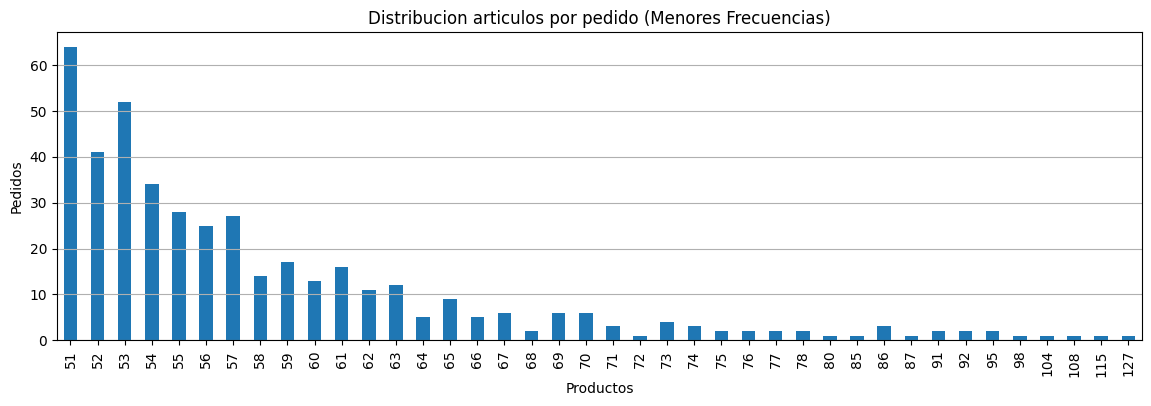

In [53]:
distribucion.plot(kind='bar',
                  title='Distribucion articulos por pedido',
                  xlabel='Productos',
                  ylabel='Pedidos',
                  figsize=[14, 4], 
                  xlim=[0, 50],
                  rot=90) 
plt.grid(True, axis='y')
plt.show()

distribucion_primeros.plot(kind='bar',
                  title='Distribucion articulos por pedido (Mayores Frecuencias)',
                  xlabel='Productos',
                  ylabel='Pedidos',
                  figsize=[14, 4],                   
                  rot=90) 
plt.grid(True, axis='y')
plt.show()

distribucion_ultimos.plot(kind='bar',
                  title='Distribucion articulos por pedido (Menores Frecuencias)',
                  xlabel='Productos',
                  ylabel='Pedidos',
                  figsize=[14, 4],                   
                  rot=90) 
plt.grid(True, axis='y')
plt.show()

Escribe aquí tus conclusiones

Cuando una tienda o mercado esta iniciando sus operaciones, las personas compran pocos productos mientras obtienen la confianza en el comercio determinado. Se puede inferir que dicha hipotesis se aplica en la plataforma de Instacart, en donde la mayoria de pedidos se registran menos de 20 articulos por pedido. Por otro lado, se observa que ya existen personas que hacen pedidos de mas de 100 productos, lo cual indica que la confianza en la plataforma y su ecosistema va en aumento.

Nota: Debido a la existencia de varias frecuencias, la grafica general NO lograba enseñar todos los datos de una manera adecuada. Es por eso, que se grafican los datos de las primeras y ultimas 40 frecuencias en graficas separadas, con la finalidad de que se pueda hacer un analisis mas asertivo.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [54]:
articulos_frecuentados = df_order_products.groupby('product_id')['reordered'].sum().sort_values(ascending=False)
print(articulos_frecuentados.head(20))

product_id
24852    55763
13176    44450
21137    28639
21903    26233
47209    23629
47766    18743
27845    16251
47626    15044
27966    14748
16797    13945
26209    13327
22935    11145
24964    10411
45007    10076
49683     9538
28204     8989
8277      8836
39275     8799
5876      8412
49235     8389
Name: reordered, dtype: int64


In [55]:
df_articulos_frecuentados = articulos_frecuentados.reset_index()
df_articulos_frecuentados.columns = ['product_id', 'reordered']
df_articulos_frecuentados = df_articulos_frecuentados.sort_values('reordered',ascending=False)
print(df_articulos_frecuentados.head(20))

    product_id  reordered
0        24852      55763
1        13176      44450
2        21137      28639
3        21903      26233
4        47209      23629
5        47766      18743
6        27845      16251
7        47626      15044
8        27966      14748
9        16797      13945
10       26209      13327
11       22935      11145
12       24964      10411
13       45007      10076
14       49683       9538
15       28204       8989
16        8277       8836
17       39275       8799
18        5876       8412
19       49235       8389


In [56]:
productos_frecuentados = df_products.merge(df_articulos_frecuentados, on='product_id', how='left')
productos_frecuentados = productos_frecuentados.sort_values('reordered',ascending=False).head(20)
print(productos_frecuentados)

       product_id              product_name  aisle_id  department_id  \
24851       24852                    Banana        24              4   
13175       13176    Bag of Organic Bananas        24              4   
21136       21137      Organic Strawberries        24              4   
21902       21903      Organic Baby Spinach       123              4   
47208       47209      Organic Hass Avocado        24              4   
47765       47766           Organic Avocado        24              4   
27844       27845        Organic Whole Milk        84             16   
47625       47626               Large Lemon        24              4   
27965       27966       Organic Raspberries       123              4   
16796       16797              Strawberries        24              4   
26208       26209                     Limes        24              4   
22934       22935      Organic Yellow Onion        83              4   
24963       24964            Organic Garlic        83           

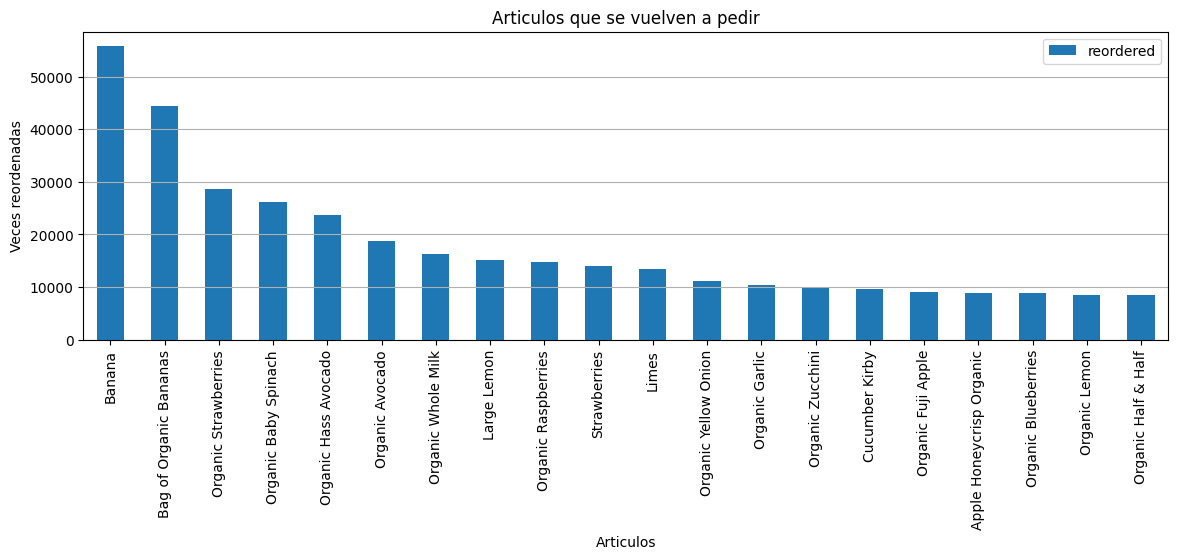

In [57]:
productos_frecuentados.plot(kind='bar',
                            x='product_name',
                            y='reordered',
                            title='Articulos que se vuelven a pedir',
                            xlabel='Articulos',
                            ylabel='Veces reordenadas',
                            figsize=[14, 4],                             
                            rot=90) 
plt.grid(True, axis='y')
plt.show()

Escribe aquí tus conclusiones

Con un comportamiento similar al de los productos mas populares, los articulos que mas vuelven a pedir los clientes corresponden aquellos encontrados en las categorias de comida saludable. De tal forma, se puede inferir que los clientes consumen dichos productos de forma recurrente para prolongar su estilo de vida sano.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [58]:
proporcion_pedidos = df_order_products.groupby('product_id')['reordered'].mean()
print(proporcion_pedidos)

product_id
1        0.564286
2        0.000000
3        0.738095
4        0.510204
7        0.500000
           ...   
49690    0.800000
49691    0.430556
49692    0.416667
49693    0.440000
49694    0.333333
Name: reordered, Length: 45573, dtype: float64


In [59]:
df_proporcion_pedidos = proporcion_pedidos.reset_index()
df_proporcion_pedidos.columns = ['product_id', 'proporcion']
print(df_proporcion_pedidos.sample(20))

       product_id  proporcion
15771       17242    0.333333
4531         4965    0.346154
44731       48782    0.000000
19898       21706    0.222222
28786       31391    0.284153
43524       47481    0.363636
22454       24472    0.200000
17377       18975    0.518519
18011       19653    0.280612
16047       17539    0.000000
43680       47645    0.666667
31379       34217    0.643590
15364       16797    0.696623
23349       25449    0.636364
26488       28869    0.000000
5183         5673    0.100000
45486       49600    0.222222
14018       15341    0.275862
11642       12772    0.685714
3490         3809    1.000000


In [60]:
df_productos_proporcion = df_products.merge(df_proporcion_pedidos, on='product_id')
print("Productos con mayor proporcion:\n\n",df_productos_proporcion.sort_values('proporcion',ascending=False).head(20))
print("\n")
print("Productos con menor proporcion:\n\n",df_productos_proporcion.sort_values('proporcion',ascending=True).head(20))

Productos con mayor proporcion:

        product_id                                       product_name  \
13453       14721                            Bone Strength Take Care   
19195       20949                           Vanilla Sandwich Cookies   
6136         6723                                   Palmiers- Petite   
6144         6732                  Naturally Sparkling Mineral Water   
41319       45088  California Dill Pollen & Garlic Goat Cheese & ...   
41310       45078                                       Pomegranatea   
19258       21016       Parchment Lined 8 in x 3.75 in x 2.5 in Pans   
19248       21005                        Peanut Butter Pie Ice Cream   
32273       35192                         Chocolate Soy Milk Singles   
32277       35197  Mocha Chocolate Chip  Organic Non-Dairy Frozen...   
6211         6810                        Raspberry Goji Paleo Prints   
41274       45040                                 Head Lock Mega Gel   
41269       45035             

Escribe aquí tus conclusiones

Se puede observar que los productos mas pedidos son aquellos de consumo rapido y recurrente, como las galletas, chocolates, cafe o cremas dentales. Al agotarse de mas rapido que otros productos, los clientes deben comprarlos seguidamente. 

En un caso contrario, los productos con menor proporcion, pueden ser aquellos que no son indispensables en el consumo de los hogares o articulos de los cuales se desconocia su existencia como Salsa de Soja Sin Gluten, Sopa Cremosa de Pimiento Rojo con Gouda Ahumado o Mezcla Orgánica para Galletas Brownie. La recurrencia puede ser mas alta, si los clientes conocen los productos y sus beneficios.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [61]:
df_usuario_reorded = df_order_products.merge(df_instacart_orders, on='order_id')
print(df_usuario_reorded.sample(20))

         order_id  product_id  add_to_cart_order  reordered  user_id  \
2001086   1362432       43295                 10          1    87935   
2353462   1107488       39561                  7          0    85737   
3788017   1673275       11182                  7          1   162206   
2495604   1280100       22935                  3          1   175398   
1998711     32834       28985                 16          1   146145   
3941991   1515341       28842                  3          1   187972   
1642237   1789913       19929                  2          0   201024   
4510325   1328580       19660                  1          1   199442   
1306728   1473640       17461                 13          0   127257   
1220187   2601043       17191                  4          1   112880   
274698    2827076       26767                 14          1   166182   
1581971    607764       41844                  9          0    70659   
2934957   2552418       32465                  8          0   13

In [62]:
reordenados_por_usuario = df_usuario_reorded.groupby('user_id')['reordered'].sum()
total_productos_por_usuario = df_usuario_reorded.groupby('user_id')['reordered'].count()
proporcion_por_usuario = reordenados_por_usuario / total_productos_por_usuario
df_proporcion_por_usuario = proporcion_por_usuario.reset_index() 
df_proporcion_por_usuario.columns = ['user_id', 'proporcion_reordered']
print(df_proporcion_por_usuario)

        user_id  proporcion_reordered
0             2              0.038462
1             4              0.000000
2             5              0.666667
3             6              0.000000
4             7              0.928571
...         ...                   ...
149621   206203              0.222222
149622   206206              0.714286
149623   206207              0.891304
149624   206208              0.696000
149625   206209              0.320000

[149626 rows x 2 columns]


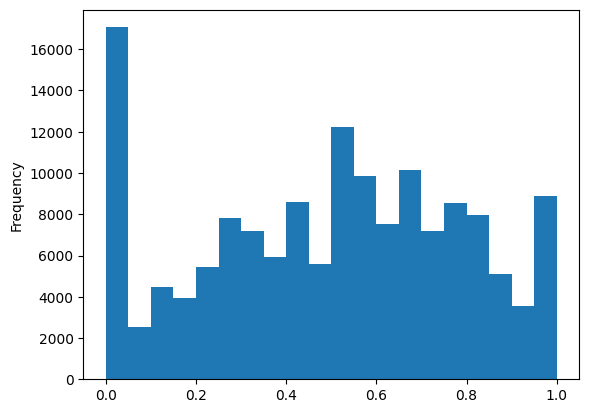

In [63]:
df_proporcion_por_usuario['proporcion_reordered'].plot(kind='hist', xlabel='Proporcion', bins=20)
plt.show()

Escribe aquí tus conclusiones

Se puede inferir que los clientes estan comprando productos de manera recurrente, lo que indica que ya usan la plataforma mas de una vez por la confianza que les genera. Esto se evidencia partiendo del hecho de que hay una cantidad importante de clientes con la proporcion de productos ya pedidos mayor al 0.5 (50%)

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [64]:
df_numero_uno = df_order_products[df_order_products['add_to_cart_order']==1]
print(df_numero_uno.sample(20))
print("\n\n")
df_numero_uno.info()

         order_id  product_id  add_to_cart_order  reordered
4180462   2401924       23044                  1          1
1721039   1177408       23986                  1          0
1800478   3051862       22915                  1          0
950336     840285        5876                  1          0
870574    2651517       18689                  1          1
3832851    107654       37687                  1          1
3697719   1399371       48726                  1          1
3278457   3024854       24852                  1          1
777001    1226594       21769                  1          1
1130334   1099135       32740                  1          0
4192229   2592578       22474                  1          0
3615669    919782       24838                  1          1
324939    2605199       19311                  1          1
2704196    535893       22035                  1          0
1175999   2759216        5212                  1          0
2474479   3154045       46720           

In [65]:
primer_producto = df_numero_uno.groupby('product_id')['add_to_cart_order'].count()
df_primer_producto = primer_producto.reset_index()
df_primer_producto.columns = ['product_id', 'add_to_cart_order_count']
print(df_primer_producto.sort_values('add_to_cart_order_count',ascending=False).head(20))
print("\n\n")
df_primer_producto.info()

       product_id  add_to_cart_order_count
13414       24852                    15562
7127        13176                    11026
15028       27845                     4363
11384       21137                     3946
25439       47209                     3390
11786       21903                     3336
25732       47766                     3044
10622       19660                     2336
9050        16797                     2308
15102       27966                     2024
24024       44632                     1914
26519       49235                     1797
25658       47626                     1737
115           196                     1733
20853       38689                     1397
14158       26209                     1370
6660        12341                     1340
3153         5785                     1310
14639       27086                     1309
23335       43352                     1246



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26760 entries, 0 to 26759
Data columns (tota

In [66]:
df_nombre_primer_producto = df_products.merge(df_primer_producto, on='product_id')
df_nombre_primer_producto = df_nombre_primer_producto.sort_values('add_to_cart_order_count',ascending=False).head(20)
print(df_nombre_primer_producto)
print("\n\n")
df_nombre_primer_producto.info()

       product_id                 product_name  aisle_id  department_id  \
13414       24852                       Banana        24              4   
7127        13176       Bag of Organic Bananas        24              4   
15028       27845           Organic Whole Milk        84             16   
11384       21137         Organic Strawberries        24              4   
25439       47209         Organic Hass Avocado        24              4   
11786       21903         Organic Baby Spinach       123              4   
25732       47766              Organic Avocado        24              4   
10622       19660                 Spring Water       115              7   
9050        16797                 Strawberries        24              4   
15102       27966          Organic Raspberries       123              4   
24024       44632   Sparkling Water Grapefruit       115              7   
26519       49235          Organic Half & Half        53             16   
25658       47626        

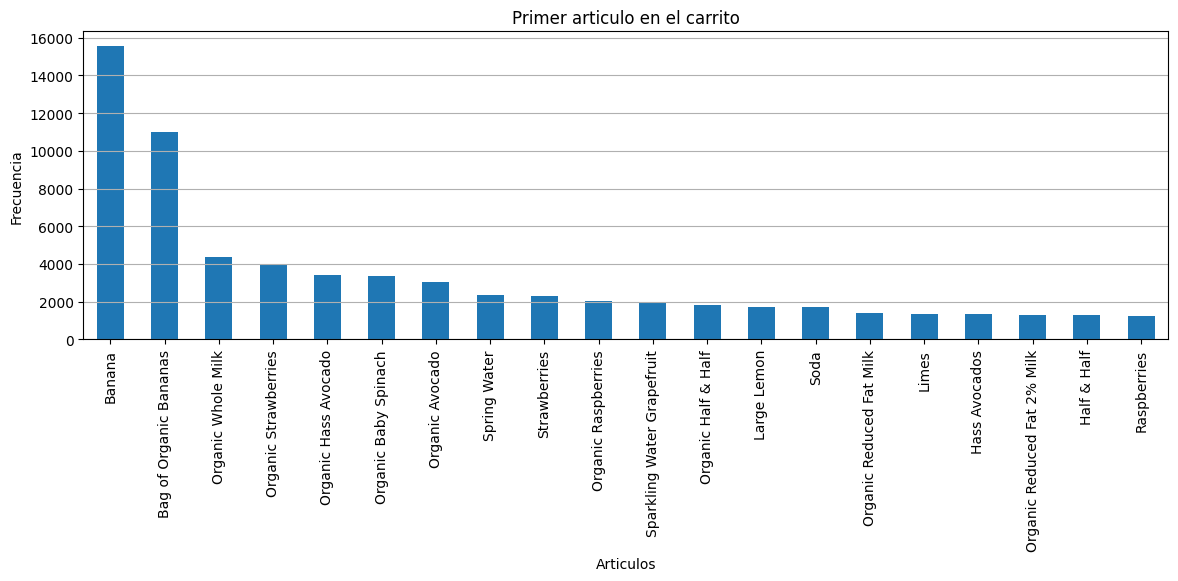

In [67]:
df_nombre_primer_producto.plot(kind='bar',
                            x='product_name',
                            y='add_to_cart_order_count',
                            title='Primer articulo en el carrito',
                            xlabel='Articulos',
                            ylabel='Frecuencia',
                            figsize=[14, 4],                             
                            rot=90, 
                            legend=False) 
plt.grid(True, axis='y')
plt.show()

Escribe aquí tus conclusiones

Se reafirma el alto interes de los consumidores en comprar productos para mantener su estilo de vida saludable.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

- Para el inciso C1, hiciste un correcto filtrado que permite observar de forma correcta como la cantidad de articulos por pedido oscila entre 7 y 10 articulos.
- Para el inciso C2 hiciste un buen uso de `.merge` para encontrar como los productos mas reordenados.
- En el punto C3 la tasa de repeticion por producto está correctamente calculada. 
- En el punto C4 hiciste un excelente uso de `groupby` para encontrar la tasa de repeticion por cliente.
- En el punto C5 hiciste un excelente filtrado para encontrar los productos que las personas escogen de primero en sus carritos.

Excelente trabajo!

### Conclusion general del proyecto:

Para garantizar un analisis coherente y aportar los datos para la toma de desiciones, es importante revisar de manera cuidadosa los datos suministrados, entendiendo su naturaleza para eliminar valores duplicados o gestionar correctamente los valores ausentes. Cabe hacer la claridad, que el uso del diccionario de datos entregado por el solicitante del analisis, fue de suma importancia para entender la naturaleza de los datos y para utilizar las columnas necesarias de cada Data frame para hacer los analisis requeridos.

En cuanto a las tendencias encontradas, se puede concluir que las horas mas frecuentes en las que se compran articulos son las se encuentran en el periodo de almuerzo; tambien se observa que los domingos y los dias 30 de cada mes son las fechas en las que mas se presentan compras de productos. En complemento, se obtuvo que los productos mas populares y aquellos que las personas priorizan, son aquellos que les permite obtener y mantener un estilo de vida saludable.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente conclusion! Has llegado al punto donde puedes nombrar las diferentes especificaciones del comportamiento de ventas de la empresa, y los hallazgos claves que señalas, como el hecho de que los usuarios tengan comportamientos periodicos y predecibles, dan mucho valor para la toma de decisiones. Te felicito por tu desempeño. 